Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Clone Repository

In [ ]:
!git clone https://github.com/shefiramarizcha62-sudo/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-.git

Cloning into 'Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 59 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 1.39 MiB | 4.16 MiB/s, done.
Resolving deltas: 100% (11/11), done.


Masuk ke Folder Project

In [ ]:
%cd Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-

/content/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-


Cek Isi Folder

In [ ]:
ls

data/  docs/  notebooks/  README.md  requirements.txt  src/


Import Library

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

Load Dataset

In [ ]:
columns = ['unit_number','time_in_cycles',
           'op_setting_1','op_setting_2','op_setting_3']

sensor_columns = [f'sensor_{i}' for i in range(1,22)]

columns.extend(sensor_columns)

train_df = pd.read_csv(
    'data/train_FD001.txt',
    sep='\s+',
    header=None
)

train_df = train_df.iloc[:,:26]

train_df.columns = columns

train_df.head()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3378/2593744736.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Hitung RUL

In [ ]:
rul = train_df.groupby('unit_number')['time_in_cycles'].max()

train_df = train_df.merge(
    rul.to_frame(name='max_cycle'),
    on='unit_number'
)

train_df['RUL'] = (
    train_df['max_cycle']
    - train_df['time_in_cycles']
)

Piece-wise RUL

In [ ]:
max_rul = 125

train_df['RUL'] = train_df['RUL'].clip(upper=max_rul)

Feature Selection

In [ ]:
sensor_cols = sensor_columns

train_df[sensor_cols].std().sort_values()

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.556432e-14
sensor_10,4.660829e-13
sensor_5,3.394700e-12
sensor_1,6.537152e-11
sensor_6,1.388985e-03
sensor_15,3.750504e-02
sensor_8,7.098548e-02
sensor_13,7.191892e-02


In [ ]:
drop_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train_df = train_df.drop(columns=drop_sensors)

Normalization

In [ ]:
features = train_df.columns.difference([
    'unit_number',
    'time_in_cycles',
    'RUL',
    'max_cycle'
])

scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(
    train_df[features]
)

Denoising

In [ ]:
train_df['sensor_2_smooth'] = (
    train_df.groupby('unit_number')['sensor_2']
    .transform(lambda x: x.rolling(5).mean())
)

In [ ]:
train_df = train_df.fillna(method='bfill')

/tmp/ipykernel_3378/1550443520.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.fillna(method='bfill')


VISUALISASI BEFORE/AFTER SMOOTHING

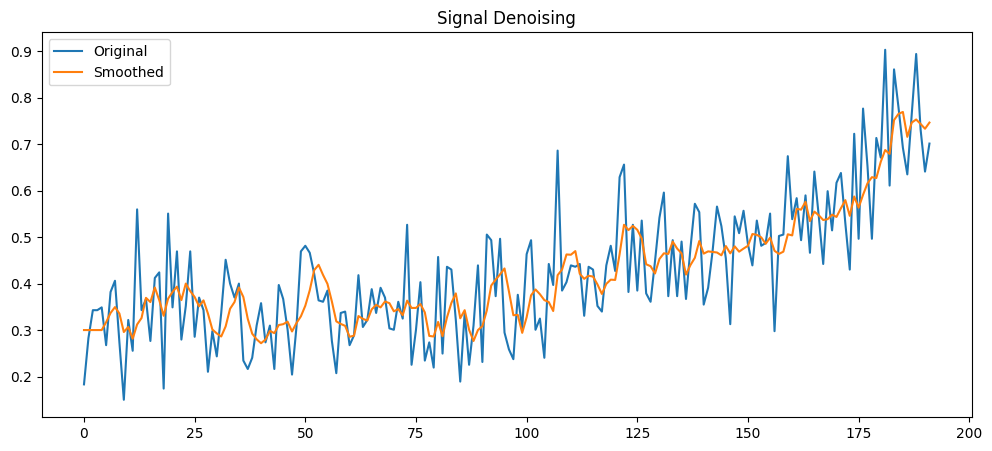

In [ ]:
engine_1 = train_df[train_df['unit_number']==1]

plt.figure(figsize=(12,5))

plt.plot(engine_1['sensor_2'], label='Original')
plt.plot(engine_1['sensor_2_smooth'], label='Smoothed')

plt.legend()
plt.title('Signal Denoising')
plt.show()

Sequence Generation

Sequence Length

In [ ]:
sequence_length = 30

Function

In [ ]:
def create_sequences(data, seq_length, feature_cols):

    X = []
    y = []

    for unit in data['unit_number'].unique():

        unit_df = data[data['unit_number']==unit].copy()

        for i in range(len(unit_df)-seq_length):

            seq_x = unit_df[feature_cols].iloc[
                i:i+seq_length
            ].values

            seq_y = unit_df['RUL'].iloc[
                i+seq_length
            ]

            X.append(seq_x)
            y.append(seq_y)

    return np.array(X), np.array(y)

Generate Sequence

In [ ]:
feature_cols = features.tolist()

X_train, y_train = create_sequences(
    train_df,
    sequence_length,
    feature_cols
)

print(X_train.shape)
print(y_train.shape)

(17631, 30, 18)
(17631,)


Save Hasil

In [ ]:
np.save('data/X_train.npy', X_train)
np.save('data/y_train.npy', y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17631, 30, 18)
y_train shape: (17631,)


# BASELINE 1D-CNN

TRAIN VALIDATION SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

IMPORT TENSORFLOW

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential([

    Input(shape=(
        X_train_split.shape[1],
        X_train_split.shape[2]
    )),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(100, activation='relu'),

    Dropout(0.3),

    Dense(1)
])

BUILD MODEL

In [ ]:
model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(
            X_train_split.shape[1],
            X_train_split.shape[2]
        )
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(100, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


COMPILE

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        89,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,321 (364.54 KB)

 Trainable params: 93,321 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [ ]:
history = model.fit(
    X_train_split,
    y_train_split,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1538.7799 - mae: 30.9016 - val_loss: 556.9315 - val_mae: 19.2109
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 606.3901 - mae: 19.7725 - val_loss: 489.0771 - val_mae: 17.6009
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 555.5235 - mae: 18.8335 - val_loss: 451.1057 - val_mae: 16.8057
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 521.5760 - mae: 18.1336 - val_loss: 422.4810 - val_mae: 16.3048
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 459.4936 - mae: 17.0551 - val_loss: 338.5661 - val_mae: 14.4862
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 392.8197 - mae: 15.6030 - val_loss: 269.7912 - val_mae: 12.8225
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 338.3856 - mae: 14.3362 - val_loss: 247.4604 - val_mae: 12.3432
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 321.7495 - mae: 14.0164 - val_loss: 230.0278 - val_mae: 11.8354
Epoch

EVALUASI

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_val)

rmse = np.sqrt(
    mean_squared_error(y_val, pred)
)

mae = mean_absolute_error(y_val, pred)

print("RMSE:", rmse)
print("MAE :", mae)

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RMSE: 14.167869127889345
MAE : 10.798675537109375


PLOT LOSS

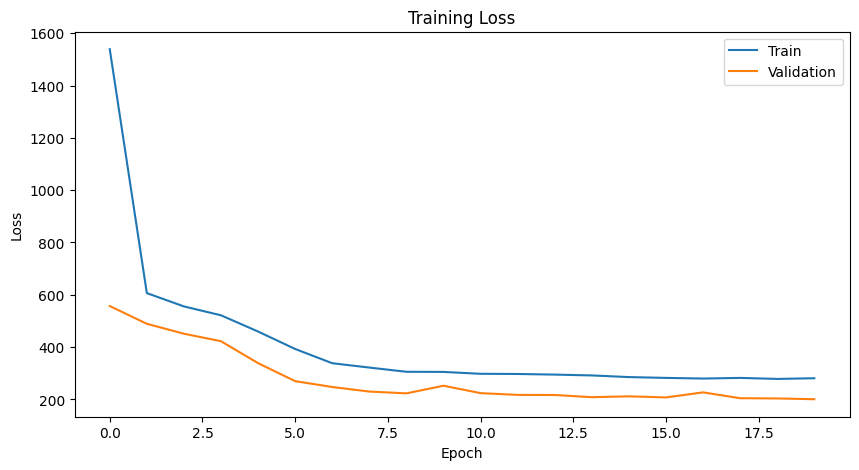

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

PLOT PREDICTION

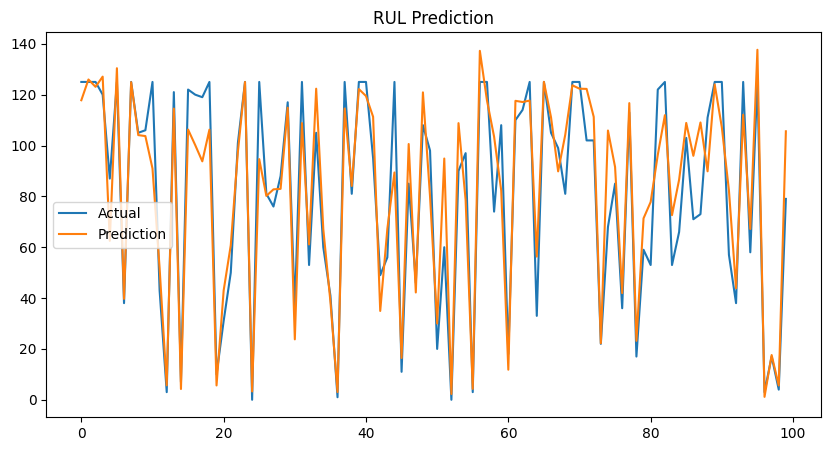

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_val[:100], label='Actual')
plt.plot(pred[:100], label='Prediction')

plt.legend()

plt.title('RUL Prediction')

plt.show()